In [1]:

import matplotlib.pyplot as plt
import pypsa
from pathlib import Path
import pandas as pd

In [2]:
REGION = "caiso_cc" # "caiso" | "new_england" | "caiso_cc"
if REGION.startswith("caiso"):
    CLUSTERS = "4"
    SIMPLE = "80"
else:
    CLUSTERS = "6"
    SIMPLE = "120"
FIGURES = Path("..","figures","marginal_costs_comparison")

In [3]:
COSTS = {
    "caiso": {
        "lgas": {
            "res": 76.26,
            "com": 76.34,
            "trn": 129.16,
            "ind": 98.85
        },
        "mgas": {
            "res": 76.31,
            "com": 76.39,
            "trn": 129.22,
            "ind": 98.94
        },
        "hgas": {
            "res": 76,
            "com": 76.1,
            "trn": 128.95,
            "ind": 98.51
        }
    },
    "new_england": {
        "lgas": {
            "res": 89.35,
            "com": 88.01,
            "trn": 128.38,
            "ind": 112.75
        },  
        "mgas": {
            "res": 89.54,
            "com": 88.2,
            "trn": 128.58,
            "ind": 112.93
        },
        "hgas": {
            "res": 90.41,
            "com": 89.06,
            "trn": 129.45,
            "ind": 113.91
        }
    },
    "caiso_cc": {
        "lgas": {
            "res": 35.56,
            "com": 35.58,
            "trn": 89.6,
            "ind": 44.59
        },
        "mgas": {
            "res": 35.52,
            "com": 35.53,
            "trn": 89.54,
            "ind": 44.57
        },
        "hgas": {
            "res": 35.97,
            "com": 34.5,
            "trn": 88.26,
            "ind": 43.34
        }
    }
}

In [4]:
FONTSIZE = 14

CARRIERS = {
    "res-total-elec": "Electricity",
    "res-total-space-heat": "Space Heat",
    # "res-total-water-heat": "Water Heat",
    "res-total-cool": "Space Cool",
    "com-total-elec": "Electricity",
    "com-total-space-heat": "Space Heat",
    # "com-total-water-heat": "Water Heat",
    "com-total-cool": "Space Cool",
    "ind-elec": "Electricity",
    "ind-heat": "Heat",
    "trn-lpg-veh": "LPG",
    "trn-elec-veh": "Electricity",
}

COLORS = {
    "Electricity": "tab:olive",
    "Space Heat": "tab:red",
    "Water Heat": "tab:purple",
    "Space Cool": "tab:blue",
    "Heat": "tab:red",
    "LPG": "tab:blue",
}

SECTORS = {"res":"Residential", "com":"Commercial", "ind":"Industrial", "trn":"Transportation"}

FIGSIZE = (12, 5)

In [5]:
def get_gas_prices(n: pypsa.Network) -> pd.Series:
    links = n.links[(n.links.carrier == ("gas trade")) & (n.links.bus0.str.contains("trade"))]
    return n.links_t["marginal_cost"][links.index].droplevel(0)

def get_elec_prices(n: pypsa.Network) -> pd.Series:
    links = n.links[n.links.carrier == "imports"]
    return n.links_t["marginal_cost"][links.index].droplevel(0)


In [6]:
def get_min_max_avg(df: pd.DataFrame, suffix: str | None = None) -> pd.Series:
    avg = df.mean(axis=1)
    sums = df.sum(axis=0)
    min_col, max_col = sums.idxmin(), sums.idxmax()
    if not suffix:
        suffix = ""
    if not min_col == max_col:
        df = df[[min_col, max_col]].rename(columns={min_col: f"min {suffix}", max_col: f"max {suffix}"})
    else:
        df = df[[min_col]].rename(columns={min_col: f"min {suffix}"})
        df[f"max {suffix}"] = df[f"min {suffix}"]
    df[f"avg {suffix}"] = avg
    return df

In [7]:
def get_ccgt_timeseries(n: pypsa.Network) -> pd.Series:
    gas_prices = get_gas_prices(n).pipe(get_min_max_avg, "CCGT")
    avg_eff = n.links[n.links.carrier == "CCGT"].efficiency.mean()
    return gas_prices / avg_eff

def get_ocgt_timeseries(n: pypsa.Network) -> pd.Series:
    gas_prices = get_gas_prices(n).pipe(get_min_max_avg, "OCGT")
    avg_eff = n.links[n.links.carrier == "OCGT"].efficiency.mean()
    return gas_prices / avg_eff

def get_elec_import_timeseries(n: pypsa.Network) -> pd.Series:
    prices = get_elec_prices(n)
    if prices.empty:
        return pd.Series()
    return get_min_max_avg(prices, "Elec Imports")

def get_dr_timeseries(region: str, scenario: str, idx: pd.Index) -> pd.DataFrame:
    price = COSTS[region][scenario]
    df = pd.DataFrame(index=idx)
    for sector in price.keys():
        df[f"{SECTORS[sector.lower()]} DR"] = price[sector]
    return df


In [8]:
def assemble_marginal_costs(n: pypsa.Network, region: str | None = None, scenario: str | None = None) -> pd.DataFrame:
    dfs = []
    if not get_ccgt_timeseries(n).empty:
        dfs.append(get_ccgt_timeseries(n))
    if not get_ocgt_timeseries(n).empty:
        dfs.append(get_ocgt_timeseries(n))
    if not get_elec_import_timeseries(n).empty:
        dfs.append(get_elec_import_timeseries(n))
    if region and scenario:
        dfs.append(get_dr_timeseries(region, scenario, dfs[0].index))
    return pd.concat(dfs, axis=1)

In [9]:
def plot_marginal_costs(n: pypsa.Network, avg: bool = True, region: str | None = None, scenario: str | None = None) -> tuple[plt.Figure, plt.Axes]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    
    color_map = {
        "dr": "k",
        "ccgt": "tab:brown",
        "ocgt": "tab:gray",
        "elec": "tab:olive",
        "residential": "tab:red",
        "commercial": "tab:green",
        "industrial": "tab:blue",
        "transportation": "tab:orange",
    }

    linestyle_map = {
        "DR": "--",
        "min": "--",
        # "max": ":",
        "max": "-",
        "avg": "-",
    }
    
    df = assemble_marginal_costs(n, region, scenario)
    
    for col in df.columns:
        
        if "min" in col and not avg:
            linestyle = linestyle_map["min"]
            color = color_map[col.split(" ")[1].lower()]
        elif "max" in col and not avg:
            linestyle = linestyle_map["max"]
            color = color_map[col.split(" ")[1].lower()]
        elif "avg" in col and avg:
            linestyle = linestyle_map["avg"]
            color = color_map[col.split(" ")[1].lower()]
        elif "DR" in col:
            linestyle = linestyle_map["DR"]
            color = color_map[col.split(" ")[0].lower()]
        else:
            continue

        df[col].plot(ax=ax, label=col, color=color, linestyle=linestyle)
    
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.75), ncol=1, frameon=False, fontsize=14)
    
    ax.set_xlabel("")
    ax.set_ylabel("Marginal cost ($/MWh)", fontsize=18)
    
    # fig.supxlabel("Hour of Year", fontsize=18)
    # fig.supylabel("Marginal Cost ($/MWh)", fontsize=18)
    
    ax.tick_params(axis="both", labelsize=12)
    
    return fig, ax

INFO:pypsa.io:Imported network elec_s80_c4m_ec_lv1.0_1h-TCT_E-G.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


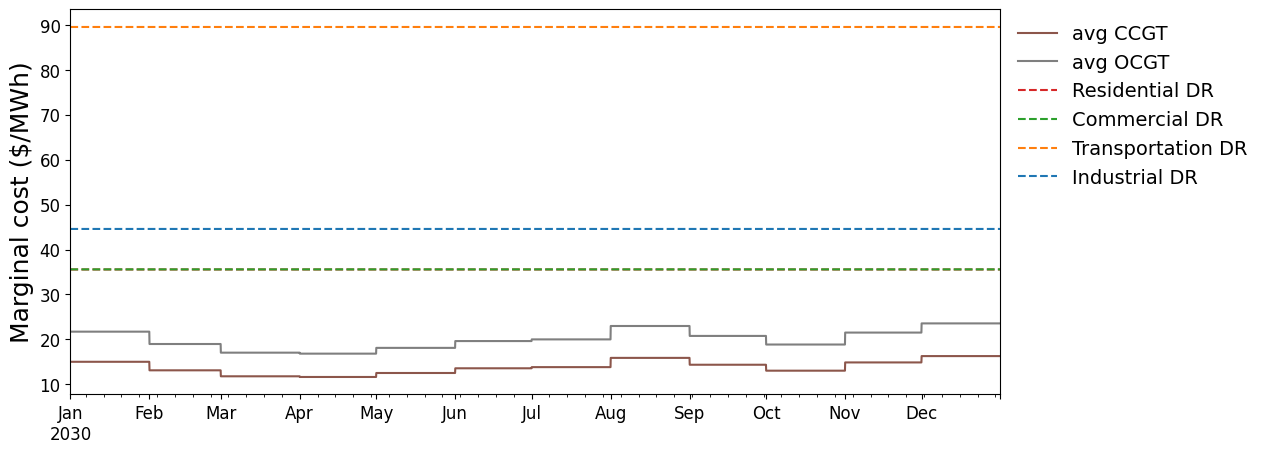

In [10]:
scenario = "lgas"
NETWORK = Path("..", "data", REGION, "raw", scenario, "networks", f"elec_s{SIMPLE}_c{CLUSTERS}m_ec_lv1.0_1h-TCT_E-G.nc")
n = pypsa.Network(NETWORK)
fig, _ = plot_marginal_costs(n, True, REGION, scenario)
save_f = Path(FIGURES, f"{scenario}.png")
save_f.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_f, dpi=300, bbox_inches="tight")

INFO:pypsa.io:Imported network elec_s80_c4m_ec_lv1.0_1h-TCT_E-G.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


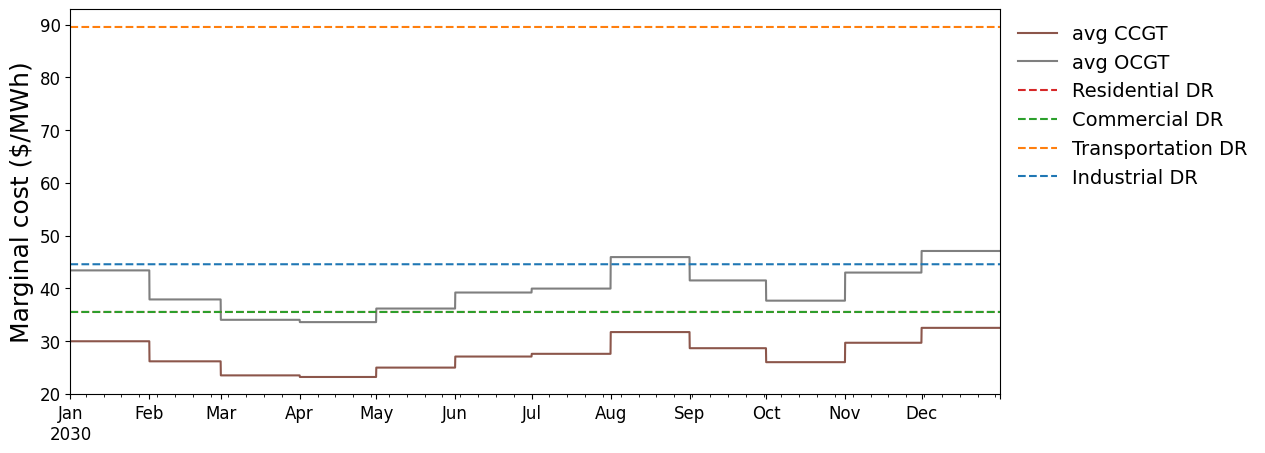

In [11]:
scenario = "mgas"
NETWORK = Path("..", "data", REGION, "raw", scenario, "networks", f"elec_s{SIMPLE}_c{CLUSTERS}m_ec_lv1.0_1h-TCT_E-G.nc")
n = pypsa.Network(NETWORK)
fig, _ = plot_marginal_costs(n, True, REGION, scenario)
save_f = Path(FIGURES, f"{scenario}.png")
save_f.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_f, dpi=300, bbox_inches="tight")

INFO:pypsa.io:Imported network elec_s80_c4m_ec_lv1.0_1h-TCT_E-G.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


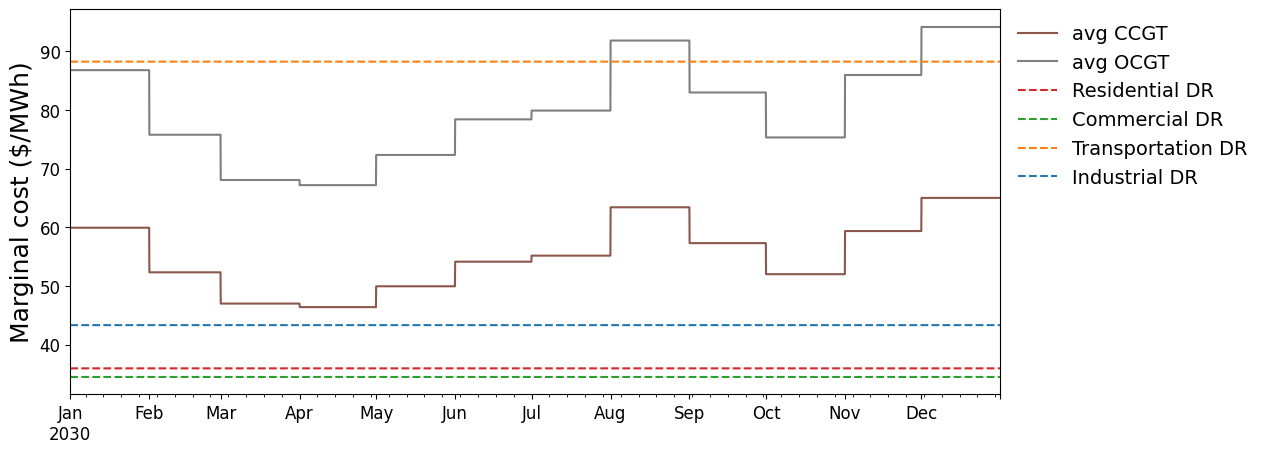

In [12]:
scenario = "hgas"
NETWORK = Path("..", "data", REGION, "raw", scenario, "networks", f"elec_s{SIMPLE}_c{CLUSTERS}m_ec_lv1.0_1h-TCT_E-G.nc")
n = pypsa.Network(NETWORK)
fig, _ = plot_marginal_costs(n, True, REGION, scenario)
save_f = Path(FIGURES, f"{scenario}.png")
save_f.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_f, dpi=300, bbox_inches="tight")